In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
import tables

sys.path.insert(0, "/data/user/akatil/electron_neutrino/for_real/analysis_chain/")

from analysis_helpers import get_mean_upgrade_positions

In [31]:
f = tables.open_file('../../dataset_complete/merger/merged_muon_neutrino_1.h5', mode='r')

In [32]:
true_2_cog = np.sqrt((f.root.TrueX.col('value') - f.root.CogX.col('value'))**2 + 
            (f.root.TrueY.col('value') - f.root.CogY.col('value'))**2 +
            (f.root.TrueZ.col('value') - f.root.CogZ.col('value'))**2 )

reco_2_cog = np.sqrt((f.root.RecoX.col('value') - f.root.CogX.col('value'))**2 + 
            (f.root.RecoY.col('value') - f.root.CogY.col('value'))**2 +
            (f.root.RecoZ.col('value') - f.root.CogZ.col('value'))**2 )

(array([6.6040e+03, 4.0561e+04, 7.6097e+04, 9.1990e+04, 9.4404e+04,
        8.7452e+04, 7.4042e+04, 5.8009e+04, 4.2211e+04, 2.9567e+04,
        1.9823e+04, 1.2815e+04, 8.3780e+03, 5.6470e+03, 3.8100e+03,
        2.7120e+03, 1.8460e+03, 1.3920e+03, 9.8100e+02, 8.0100e+02,
        5.8400e+02, 4.1900e+02, 3.3000e+02, 2.7100e+02, 1.6200e+02,
        1.5500e+02, 9.9000e+01, 6.6000e+01, 5.6000e+01, 3.4000e+01,
        2.0000e+01, 9.0000e+00, 1.9000e+01, 1.0000e+01, 9.0000e+00,
        5.0000e+00, 0.0000e+00, 3.0000e+00, 1.0000e+00, 3.0000e+00,
        1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([2.52324221e-01, 4.70942360e+00, 9.1665

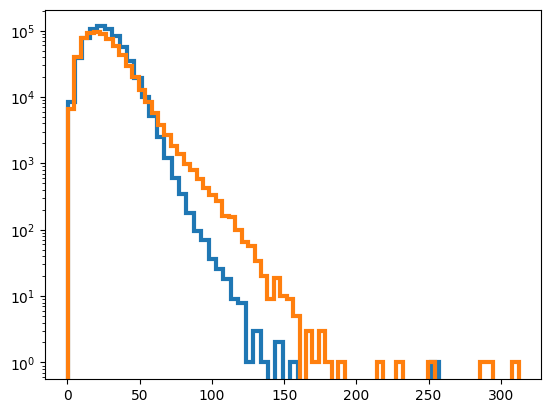

In [33]:
plt.hist(true_2_cog, bins=50, histtype='step', lw=3, log=True)
plt.hist(reco_2_cog, bins=70,  histtype='step', lw=3, log=True)

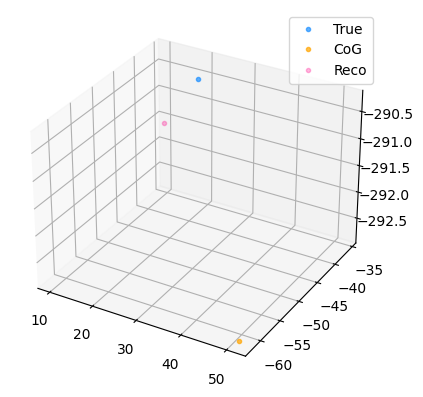

In [34]:
fig = plt.figure()
ax = plt.axes(projection='3d')

index = true_2_cog < reco_2_cog
index1 = 6424

ax.plot3D(f.root.TrueX.col('value')[index][index1], f.root.TrueY.col('value')[index][index1], f.root.TrueZ.col('value')[index][index1], '.', c='dodgerblue', alpha=0.7, label='True')
ax.plot3D(f.root.CogX.col('value')[index][index1], f.root.CogY.col('value')[index][index1], f.root.CogZ.col('value')[index][index1], '.', c='orange', alpha=0.7, label='CoG')
ax.plot3D(f.root.RecoX.col('value')[index][index1], f.root.RecoY.col('value')[index][index1], f.root.RecoZ.col('value')[index][index1], '.', c='deeppink', alpha=0.3, label='Reco')
plt.legend()
plt.show()

In [35]:
len(f.root.TrueX.col('value')[true_2_cog < reco_2_cog])

277007

In [36]:
len(f.root.TrueX.col('value')[true_2_cog > reco_2_cog])

384398